In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### we also have sklearn classes
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report as CR, confusion_matrix as cm


In [2]:
# let's grab some data
data = pd.read_csv('https://github.com/dvasiliu/AML/blob/main/Data%20Sets/ElectricalGridData.csv?raw=true')

In [3]:
data

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385,0.023892,unstable
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120,-0.025803,stable
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984,-0.031810,stable
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391,0.037789,unstable


In [3]:
# I need an x and an y
x = data.loc[:,"tau1":"g4"].values
y = data['stabf'].values

In [8]:
labeler = LabelEncoder()
y = labeler.fit_transform(y)

In [9]:
y

array([1, 0, 1, ..., 0, 1, 1], shape=(10000,))

In [8]:
y[y=='unstable']=1

In [9]:
y[y=='stable']=0

In [19]:
y = y.reshape(-1,1).astype('int64')

In [11]:
model = LogisticRegression(C=100,max_iter=1000)

In [12]:
model.fit(x,y)

LogisticRegression(C=100, max_iter=1000)

In [13]:
model.score(x,y)

0.8166

In [14]:
print(CR(y,model.predict(x)))

              precision    recall  f1-score   support

           0       0.77      0.71      0.74      3620
           1       0.84      0.88      0.86      6380

    accuracy                           0.82     10000
   macro avg       0.80      0.79      0.80     10000
weighted avg       0.81      0.82      0.81     10000



In [15]:
pd.DataFrame(data=cm(y,model.predict(x)),columns=['0','1'],index=['0','1'])

,0,1
0,2557,1063
1,771,5609


In [25]:
2556/(2556+1064)

0.7060773480662983

To improve and reduce the algorithmic bias, let's apply SVM.

In [16]:
model = SVC(kernel='poly',degree=2,C=2)
model.fit(x,y)

SVC(C=2, degree=2, kernel='poly')

In [17]:
print(CR(y,model.predict(x)))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      3620
           1       0.92      0.93      0.93      6380

    accuracy                           0.91     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.91      0.91      0.91     10000



In [39]:
CR(y,model.predict(x),output_dict=True)

{'0': {'precision': 0.9064215148188803,
  'recall': 0.9124309392265193,
  'f1-score': 0.9094162995594713,
  'support': 3620.0},
 '1': {'precision': 0.9501258653241033,
  'recall': 0.946551724137931,
  'f1-score': 0.9483354271356784,
  'support': 6380.0},
 'accuracy': 0.9342,
 'macro avg': {'precision': 0.9282736900714919,
  'recall': 0.9294913316822251,
  'f1-score': 0.9288758633475749,
  'support': 10000.0},
 'weighted avg': {'precision': 0.9343048904412126,
  'recall': 0.9342,
  'f1-score': 0.9342467029530915,
  'support': 10000.0}}

In [42]:
model = SVC(kernel='rbf',C=2,gamma=0.05)
model.fit(x,y.ravel())
print(CR(y,model.predict(x)))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      3620
           1       0.96      0.98      0.97      6380

    accuracy                           0.96     10000
   macro avg       0.96      0.95      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [44]:
# let's do 10-Fold CV from scratch

# first, to shuffle
shuffle = np.random.permutation(range(len(x)))

In [51]:
# second, we need the folds
ind = np.array_split(shuffle,10)[0]

In [52]:
np.delete(range(len(x)),ind)

array([   0,    1,    2, ..., 9996, 9997, 9999], shape=(9000,))

In [56]:
reports = []
for ind in np.array_split(shuffle,10):
    xtest = x[ind]
    ytest = y[ind]
    xtrain = x[np.delete(range(len(x)),ind)]
    ytrain = y[np.delete(range(len(x)),ind)]
    model = SVC(kernel='rbf',C=2,gamma=0.05)
    model.fit(xtrain,ytrain.ravel())
    print(model.score(xtest,ytest))
    reports.append(CR(ytest,model.predict(xtest),output_dict=True))

0.925
0.939
0.941
0.936
0.953
0.938
0.937
0.954
0.955
0.934


In [64]:
reports[0]['0']['recall']

0.8774373259052924

## We rather want to use a Stratified K-Fold Cross-Validation

In [18]:
from sklearn.model_selection import StratifiedKFold

In [19]:
skf = StratifiedKFold(n_splits=5,shuffle=True, random_state=301)

In [20]:
skf.split(x,y)

<generator object _BaseKFold.split at 0x7f3c97a5a240>

In [21]:
# let's show how to find the best C in a range
# we can, for example, track the test scores from a Stratified KFold 
def objective(model):
    test_scores = []
    for indtrain, indtest in skf.split(x,y):
        xtrain = x[indtrain]
        ytrain = y[indtrain]
        xtest =  x[indtest]
        ytest = y[indtest]
        model.fit(xtrain,ytrain)
        test_scores.append(model.score(xtest,ytest))
    return np.mean(test_scores)

In [22]:
model = SVC(kernel='poly',degree=2,C=1)
objective(model)

np.float64(0.8869)

In [23]:
_C_range = np.arange(1,20.5,0.5)

In [ ]:
best_score = 0.0
best_C = None
for _C in _C_range:
    model = SVC(kernel='poly',degree=2,C=_C)
    if objective(model)>best_score:
        best_score = objective(model)
        best_C = _C


In [29]:
best_C

np.float64(18.0)

In [31]:
model = SVC(kernel='poly',degree=2,C=18)
model.fit(x,y)
pd.DataFrame(data=cm(y,model.predict(x)),columns=['0','1'],index=['0','1'])

,0,1
0,3258,362
1,304,6076


## How to create the ROC curve

In [32]:
# no coding from scratch here, just use the library 
from sklearn.metrics import RocCurveDisplay,auc, roc_curve

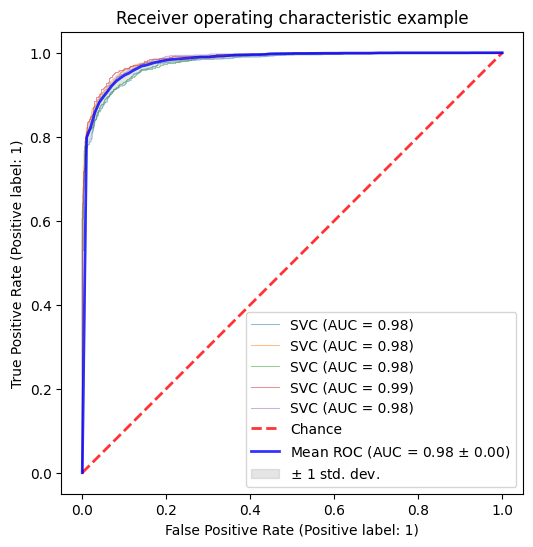

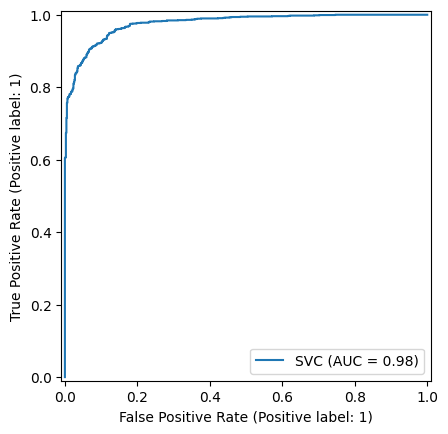

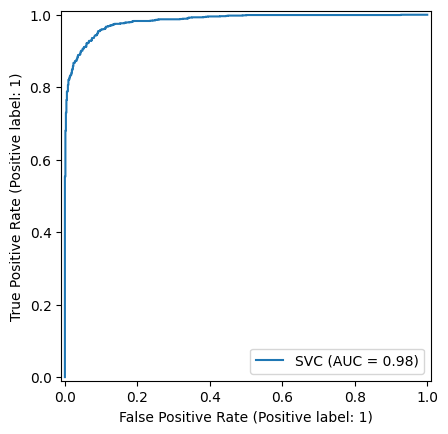

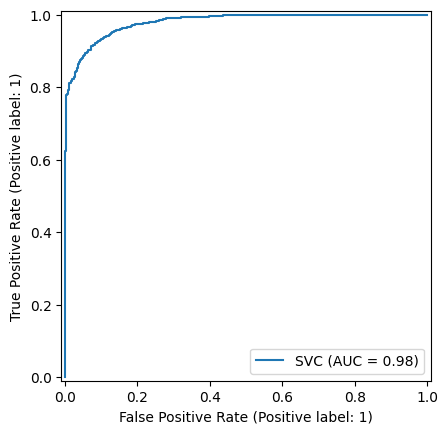

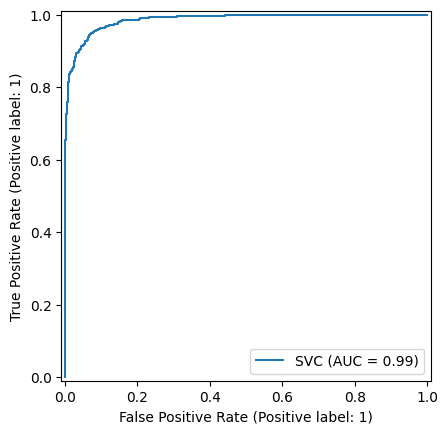

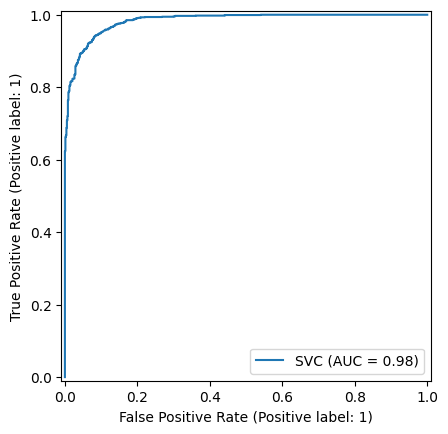

In [35]:
n_samples, n_features = x.shape


# #############################################################################
# Classification and ROC analysis

# Run classifier with cross-validation and plot ROC curves
cv = StratifiedKFold(n_splits=5,shuffle = True,random_state=301)
#classifier = SVC(kernel='rbf', gamma=0.0001,probability=True,random_state=310)
#classifier = LogisticRegression(solver='lbfgs',max_iter=100000)
classifier = SVC(kernel='poly',degree=2,C=18,probability=True)

# define tracker variables
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100) # for the horizontal axis

fig,ax = plt.subplots(figsize=(6,6))
for i, (train, test) in enumerate(cv.split(x, y)):
    classifier.fit(x[train], y[train])
    viz = RocCurveDisplay.from_estimator(classifier, x[test], y[test])
    viz.plot(ax=ax,alpha=0.5,lw=0.75)
    fpr, tpr, thresholds = roc_curve(y[test], classifier.predict_proba(x[test])[:,1])
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Chance', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="Receiver operating characteristic example")
ax.legend(loc="lower right")
plt.show()

## Multiclass Calssification

Let's import the mobile data set 


In [36]:
data = pd.read_csv('https://github.com/dvasiliu/AML/blob/main/Data%20Sets/mobile.csv?raw=true')

In [37]:
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [47]:
# we want to know how many classes to we predict for in the price range
data['price_range'].unique()
y = data['price_range'].values
x = data.loc[:,'battery_power':'wifi'].values

In [39]:
# the features have different order of magnitudes so we want to scale them
scale = StandardScaler()

In [48]:
model = LogisticRegression(C=100,max_iter=1000)
model.fit(scale.fit_transform(x),y)

LogisticRegression(C=100, max_iter=1000)

In [49]:
xscaled = scale.fit_transform(x)

In [50]:
model.predict_proba([xscaled[9]])

array([[1.00000000e+00, 9.58002092e-14, 3.08607764e-38, 2.18862600e-76]])

In [42]:
# let's show a Confusion Matrix
cm(y,model.predict(scale.fit_transform(x)))

array([[499,   1,   0,   0],
       [  4, 490,   6,   0],
       [  0,   4, 490,   6],
       [  0,   0,   7, 493]])

In [44]:
model = LogisticRegression(C=100,max_iter=1000)

In [45]:
# we would prefer a complete stratified K-Fold cross-validation
def objective(model):
    test_scores = []
    for indtrain, indtest in skf.split(x,y):
        xtrain = scale.fit_transform(x[indtrain])
        ytrain = y[indtrain]
        xtest =  scale.transform(x[indtest])
        ytest = y[indtest]
        model.fit(xtrain,ytrain)
        test_scores.append(model.score(xtest,ytest))
    return np.mean(test_scores)

In [46]:
objective(model)

np.float64(0.9705000000000001)